In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import matplotlib as mpl
from pynamicalsys import DiscreteDynamicalSystem as dds
from joblib import Parallel, delayed
from pynamicalsys import PlotStyler

ps = PlotStyler()
ps.apply_style()

<Figure size 640x480 with 0 Axes>

# Uncertainty Exponent

## Henon Map

In [2]:
@njit
def henon_map(state: np.ndarray, parameters: np.ndarray) -> np.ndarray:
    x, y = state
    a, b = parameters
    return np.array([1 - (a*x**2) + y, b*x])


henon = dds(
    mapping=henon_map,
    number_of_parameters=2,
    system_dimension=2,
    )

### Basins

In [3]:
exists = np.array([[-10, 10], [-10, 10]], dtype=np.float64)
N = 2_000
grid_size = 1_000
x_range = (-2, 2)
y_range = (-2, 2)
x = np.linspace(x_range[0], x_range[1], grid_size)
y = np.linspace(y_range[0], y_range[1], grid_size)
X, Y = np.meshgrid(x, y, indexing='ij')

grid_points = [np.array([X[i, j], Y[i, j]]) for i in range(grid_size) for j in range(grid_size)]


In [4]:
escape_smooth = np.array(Parallel(n_jobs=-1)(
        delayed(henon.escape_analysis)(
            u, N, exists,parameters=[1.40, 0.3], escape="exiting"
        ) 
        for u in grid_points
    )
)

escape_fractal = np.array(Parallel(n_jobs=-1)(
        delayed(henon.escape_analysis)(
            u, N, exists, parameters=[1.45, 0.3], escape="exiting"
        ) 
        for u in grid_points
    )
)
basin_fractal = escape_fractal[:, 0].reshape(grid_size, grid_size)

basin_smooth = escape_smooth[:, 0].reshape(grid_size, grid_size)

In [5]:
np.unique(escape_smooth[:, 0])

array([-1,  0])

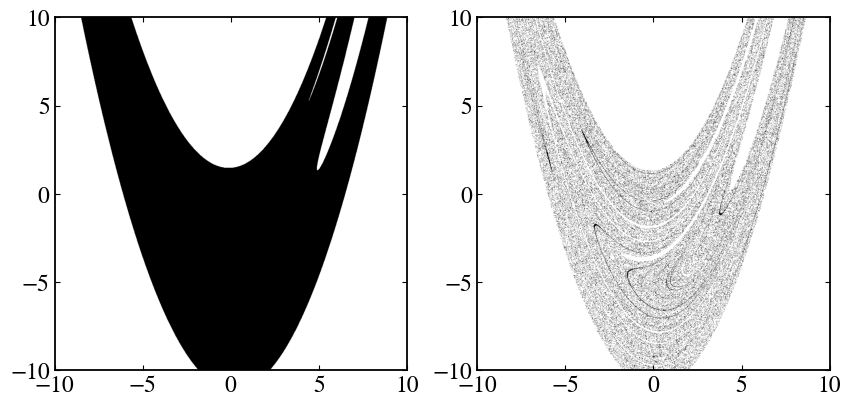

In [6]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].imshow(basin_smooth.T, origin='lower', extent=exists.flatten(),cmap="binary_r")
ax[1].imshow(basin_fractal.T,origin='lower', extent=exists.flatten(), cmap="binary_r")

# Uncertainty Exponent

In [7]:
from pynamicalsys import BasinMetrics

In [8]:
metric_smooth = BasinMetrics(basin_smooth)
metric_fractal = BasinMetrics(basin_fractal)

In [9]:
epsilons_s, f_s = metric_smooth.uncertainty_fraction(X, Y)
epsilons_f, f_f = metric_fractal.uncertainty_fraction(X, Y)

In [10]:
epsilons_s, f_s

(array([0.004004  , 0.00413629, 0.00427294, 0.00441411, 0.00455994,
        0.00471059, 0.00486622, 0.00502699, 0.00519307, 0.00536464,
        0.00554187, 0.00572497, 0.00591411, 0.0061095 , 0.00631134,
        0.00651985, 0.00673525, 0.00695777, 0.00718764, 0.00742511,
        0.00767041, 0.00792383, 0.00818561, 0.00845605, 0.00873542,
        0.00902402, 0.00932215, 0.00963013, 0.00994829, 0.01027696,
        0.01061649, 0.01096724, 0.01132957, 0.01170387, 0.01209055,
        0.01248999, 0.01290263, 0.01332891, 0.01376926, 0.01422417,
        0.01469411, 0.01517957, 0.01568107, 0.01619914, 0.01673432,
        0.01728718, 0.01785832, 0.01844832, 0.01905781, 0.01968744,
        0.02033786, 0.02100978, 0.0217039 , 0.02242095, 0.02316169,
        0.0239269 , 0.02471739, 0.025534  , 0.02637759, 0.02724905,
        0.0281493 , 0.02907929, 0.03004   , 0.03103246, 0.0320577 ,
        0.03311682, 0.03421093, 0.03534118, 0.03650878, 0.03771495,
        0.03896096, 0.04024815, 0.04157786, 0.04

In [11]:
epsilons_f, f_f

(array([0.004004  , 0.00413629, 0.00427294, 0.00441411, 0.00455994,
        0.00471059, 0.00486622, 0.00502699, 0.00519307, 0.00536464,
        0.00554187, 0.00572497, 0.00591411, 0.0061095 , 0.00631134,
        0.00651985, 0.00673525, 0.00695777, 0.00718764, 0.00742511,
        0.00767041, 0.00792383, 0.00818561, 0.00845605, 0.00873542,
        0.00902402, 0.00932215, 0.00963013, 0.00994829, 0.01027696,
        0.01061649, 0.01096724, 0.01132957, 0.01170387, 0.01209055,
        0.01248999, 0.01290263, 0.01332891, 0.01376926, 0.01422417,
        0.01469411, 0.01517957, 0.01568107, 0.01619914, 0.01673432,
        0.01728718, 0.01785832, 0.01844832, 0.01905781, 0.01968744,
        0.02033786, 0.02100978, 0.0217039 , 0.02242095, 0.02316169,
        0.0239269 , 0.02471739, 0.025534  , 0.02637759, 0.02724905,
        0.0281493 , 0.02907929, 0.03004   , 0.03103246, 0.0320577 ,
        0.03311682, 0.03421093, 0.03534118, 0.03650878, 0.03771495,
        0.03896096, 0.04024815, 0.04157786, 0.04

In [12]:
def calc_fractal_dimension(eps, f_eps):
    valid = (f_eps > 0) & np.isfinite(f_eps)
    if not np.any(valid):
        return None 
    log_e = np.log10(eps[valid])
    log_f = np.log10(f_eps[valid])

    coeffs = np.polyfit(log_e, log_f, 1)
    alpha = float(coeffs[0])
    log_C = float(coeffs[1])

    dimension = 2 - alpha
    log_f_pred = alpha * log_e + log_C

    ss_res = np.sum((log_f - log_f_pred) ** 2)  # soma dos resíduos
    ss_tot = np.sum((log_f - log_f.mean()) ** 2)  # soma dos quadratos total
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

    return alpha, dimension, log_C, r2, valid

results_smooth = calc_fractal_dimension(epsilons_s, f_s)
results_fractal = calc_fractal_dimension(epsilons_f, f_f)

In [13]:
alpha_s, dimension_s, log_C_s, r2_s, valid_s = results_smooth
alpha_f, dimension_f, log_C_f, r2_f, valid_f = results_fractal

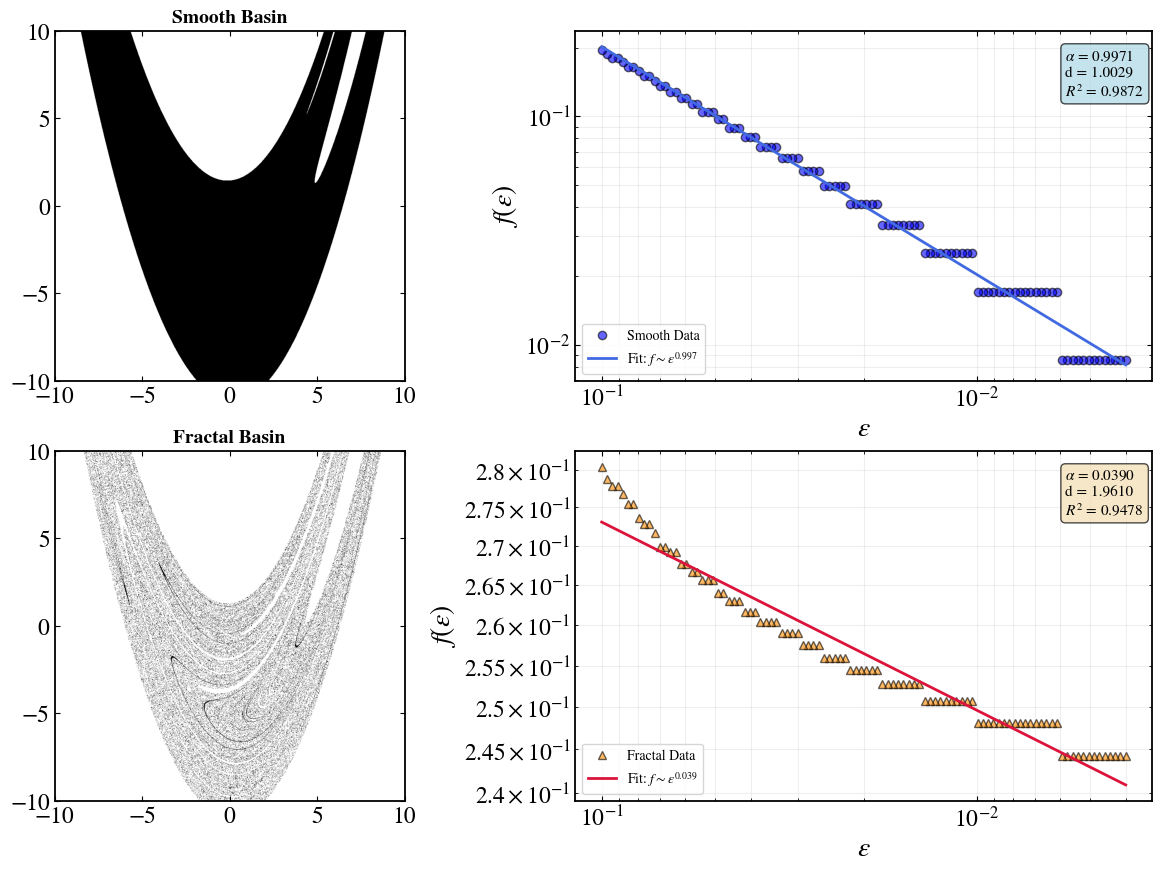

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], hspace=0.2, wspace=0.2)

# ==============================================================================
# LINE 1: SMOOTH SYSTEM
# ==============================================================================

# Ax 0: 
ax_basin_s = fig.add_subplot(gs[0, 0])
ax_basin_s.imshow(basin_smooth.T, origin='lower', extent=exists.flatten(), cmap="binary_r")
ax_basin_s.set_title("Smooth Basin", fontsize=14, fontweight='bold')

# Ax 1:
ax_plot_s = fig.add_subplot(gs[0, 1])
valid_s = f_s >= 0
ax_plot_s.loglog(epsilons_s[valid_s], f_s[valid_s], 'o', markersize=6, 
                 label='Smooth Data', alpha=0.6, color='blue')

if not np.isnan(alpha_s):
    eps_fit_s = np.logspace(np.log10(epsilons_s[valid_s].min()), np.log10(epsilons_s[valid_s].max()), 200)
    C_s = 10**log_C_s
    frac_fit_s = C_s * eps_fit_s**alpha_s
    ax_plot_s.loglog(eps_fit_s, frac_fit_s, linewidth=2.0, color='royalblue',
                     label=r'Fit: $f \sim ε^{'+f'{alpha_s:.3f}'+r'}$')
    
    text_s = f'$\\alpha$ = {alpha_s:.4f}\nd = {dimension_s:.4f}\n$R^2$ = {r2_s:.4f}'
    ax_plot_s.text(0.85, 0.95, text_s, transform=ax_plot_s.transAxes, fontsize=11, 
                  verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

ax_plot_s.set_xlabel(r'$\varepsilon$')
ax_plot_s.set_ylabel(r'$f(\varepsilon)$')
ax_plot_s.grid(True, alpha=0.3, linestyle='--')
ax_plot_s.invert_xaxis()
ax_plot_s.minorticks_on()
ax_plot_s.grid(True, which='both', linestyle='-', alpha=0.2)
ax_plot_s.legend(loc='lower left', fontsize=10)

# ==============================================================================
# LINE 2: FRACTAL SYSTEM
# ==============================================================================

# Ax 2: 
ax_basin_f = fig.add_subplot(gs[1, 0])
ax_basin_f.imshow(basin_fractal.T, origin='lower', extent=exists.flatten(), cmap="binary_r")
ax_basin_f.set_title("Fractal Basin", fontsize=14, fontweight='bold')

# Ax 3: 
ax_plot_f = fig.add_subplot(gs[1, 1])
valid_f = f_f >= 0
ax_plot_f.loglog(epsilons_f[valid_f], f_f[valid_f], '^', markersize=6, 
                 label='Fractal Data', alpha=0.6, color='darkorange')

if not np.isnan(alpha_f):
    eps_fit_f = np.logspace(np.log10(epsilons_f[valid_f].min()), np.log10(epsilons_f[valid_f].max()), 200)
    C_f = 10**log_C_f
    frac_fit_f = C_f * eps_fit_f**alpha_f
    ax_plot_f.loglog(eps_fit_f, frac_fit_f, linewidth=2.0, color='crimson',
                     label=r'Fit: $f \sim ε^{'+f'{alpha_f:.3f}'+r'}$')
    
    text_f = f'$\\alpha$ = {alpha_f:.4f}\nd = {dimension_f:.4f}\n$R^2$ = {r2_f:.4f}'
    ax_plot_f.text(0.85, 0.95, text_f, transform=ax_plot_f.transAxes, fontsize=11, 
                  verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax_plot_f.set_xlabel(r'$\varepsilon$')
ax_plot_f.set_ylabel(r'$f(\varepsilon)$')
ax_plot_f.grid(True, alpha=0.3, linestyle='--')
ax_plot_f.invert_xaxis()
ax_plot_f.minorticks_on()
ax_plot_f.grid(True, which='both', linestyle='-', alpha=0.2)
ax_plot_f.legend(loc='lower left', fontsize=10)

# plt.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.95)
plt.show()


## Using mapping

In [15]:
%%time
epsilons_s2, f_s2 = metric_smooth.uncertainty_fraction_mapping(
    X, Y,
    mapping      = henon,
    parameters   = [1.40, 0.3],
    exits        = exists,
    n_samples    = 10_000,
    p_samples    = 7,
    max_time     = N,
)

CPU times: user 612 ms, sys: 97.8 ms, total: 710 ms
Wall time: 1min 43s


In [16]:
epsilons_s2, f_s2 = np.array(epsilons_s2), np.array(f_s2)
results_smooth2 = calc_fractal_dimension(epsilons_s2, f_s2)
results_smooth2

(0.7744070698521138,
 1.225592930147886,
 -0.297729938296201,
 0.9548267689929787,
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
        False, False, False, False, False, False, False, False, False,
        False]))

In [17]:
%%time
epsilons_f2, f_f2 = metric_fractal.uncertainty_fraction_mapping(
    X, Y,
    mapping      = henon,
    parameters   = [1.45, 0.3],
    exits        = exists,
    n_samples    = 10_000,
    p_samples    = 7,
    max_time     = N,
)

CPU times: user 480 ms, sys: 46.6 ms, total: 527 ms
Wall time: 31.7 s


In [18]:
epsilons_f2, f_f2 = np.array(epsilons_f2), np.array(f_f2)
results_fractal2 = calc_fractal_dimension(epsilons_f2, f_f2)
results_fractal2

(0.03414167406722408,
 1.965858325932776,
 -0.4387050330076616,
 0.993324077367421,
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]))

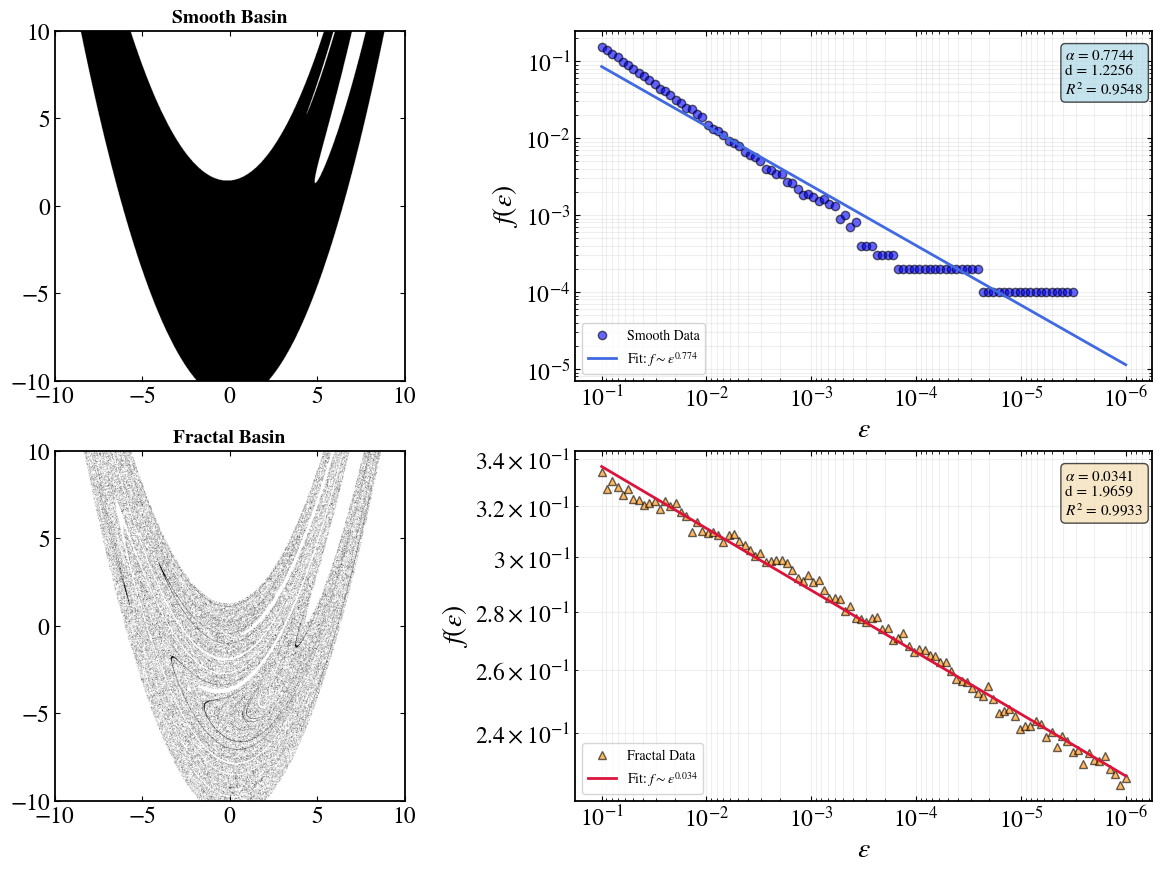

In [19]:
alpha_s, dimension_s, log_C_s, r2_s, valid_s = results_smooth2
alpha_f, dimension_f, log_C_f, r2_f, valid_f = results_fractal2
# -----------------------------------------------------------------------------

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], hspace=0.2, wspace=0.2)

# ==============================================================================
# LINE 1: SMOOTH SYSTEM
# ==============================================================================

# Ax 0: 
ax_basin_s = fig.add_subplot(gs[0, 0])
ax_basin_s.imshow(basin_smooth.T, origin='lower', extent=exists.flatten(), cmap="binary_r")
ax_basin_s.set_title("Smooth Basin", fontsize=14, fontweight='bold')

# Ax 1:
ax_plot_s = fig.add_subplot(gs[0, 1])
valid_s = f_s2 >= 0
ax_plot_s.loglog(epsilons_s2[valid_s], f_s2[valid_s], 'o', markersize=6, 
                 label='Smooth Data', alpha=0.6, color='blue')

if not np.isnan(alpha_s):
    eps_fit_s = np.logspace(np.log10(epsilons_s2[valid_s].min()), np.log10(epsilons_s2[valid_s].max()), 200)
    C_s = 10**log_C_s
    frac_fit_s = C_s * eps_fit_s**alpha_s
    ax_plot_s.loglog(eps_fit_s, frac_fit_s, linewidth=2.0, color='royalblue',
                     label=r'Fit: $f \sim ε^{'+f'{alpha_s:.3f}'+r'}$')
    
    text_s = f'$\\alpha$ = {alpha_s:.4f}\nd = {dimension_s:.4f}\n$R^2$ = {r2_s:.4f}'
    ax_plot_s.text(0.85, 0.95, text_s, transform=ax_plot_s.transAxes, fontsize=11, 
                  verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

ax_plot_s.set_xlabel(r'$\varepsilon$')
ax_plot_s.set_ylabel(r'$f(\varepsilon)$')
ax_plot_s.grid(True, alpha=0.3, linestyle='--')
ax_plot_s.invert_xaxis()
ax_plot_s.minorticks_on()
ax_plot_s.grid(True, which='both', linestyle='-', alpha=0.2)
ax_plot_s.legend(loc='lower left', fontsize=10)

# ==============================================================================
# LINE 2: FRACTAL SYSTEM
# ==============================================================================

# Ax 2: 
ax_basin_f = fig.add_subplot(gs[1, 0])
ax_basin_f.imshow(basin_fractal.T, origin='lower', extent=exists.flatten(), cmap="binary_r")
ax_basin_f.set_title("Fractal Basin", fontsize=14, fontweight='bold')

# Ax 3: 
ax_plot_f = fig.add_subplot(gs[1, 1])
valid_f = f_f2 >= 0
ax_plot_f.loglog(epsilons_f2[valid_f], f_f2[valid_f], '^', markersize=6, 
                 label='Fractal Data', alpha=0.6, color='darkorange')

if not np.isnan(alpha_f):
    eps_fit_f = np.logspace(np.log10(epsilons_f2[valid_f].min()), np.log10(epsilons_f2[valid_f].max()), 200)
    C_f = 10**log_C_f
    frac_fit_f = C_f * eps_fit_f**alpha_f
    ax_plot_f.loglog(eps_fit_f, frac_fit_f, linewidth=2.0, color='crimson',
                     label=r'Fit: $f \sim ε^{'+f'{alpha_f:.3f}'+r'}$')
    
    text_f = f'$\\alpha$ = {alpha_f:.4f}\nd = {dimension_f:.4f}\n$R^2$ = {r2_f:.4f}'
    ax_plot_f.text(0.85, 0.95, text_f, transform=ax_plot_f.transAxes, fontsize=11, 
                  verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax_plot_f.set_xlabel(r'$\varepsilon$')
ax_plot_f.set_ylabel(r'$f(\varepsilon)$')
ax_plot_f.grid(True, alpha=0.3, linestyle='--')
ax_plot_f.invert_xaxis()
ax_plot_f.minorticks_on()
ax_plot_f.grid(True, which='both', linestyle='-', alpha=0.2)
ax_plot_f.legend(loc='lower left', fontsize=10)

# plt.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.95)
plt.show()
